In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from PIL import Image

In [2]:
transforms_basic = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

In [3]:
data_dir = "../data/processed"

full_dataset = datasets.ImageFolder(root=data_dir, transform=transforms_basic)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

class_names = full_dataset.classes

In [4]:
def create_resnet18_model(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = len(class_names)

model = create_resnet18_model(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
epochs = 10
loss_history = []

for epoch in range(epochs):
    running_loss = 0.0
    model.train()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

Epoch 1/10, Loss: 1.1745
Epoch 2/10, Loss: 0.7447
Epoch 3/10, Loss: 0.5702
Epoch 4/10, Loss: 0.2588
Epoch 5/10, Loss: 0.1977
Epoch 6/10, Loss: 0.1120
Epoch 7/10, Loss: 0.2882
Epoch 8/10, Loss: 0.3936
Epoch 9/10, Loss: 0.3051
Epoch 10/10, Loss: 0.3854


In [6]:
def evaluate(model, val_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

val_accuracy = evaluate(model, val_loader)
print(f"Validation Accuracy: {val_accuracy:.2f}%")

Validation Accuracy: 80.00%


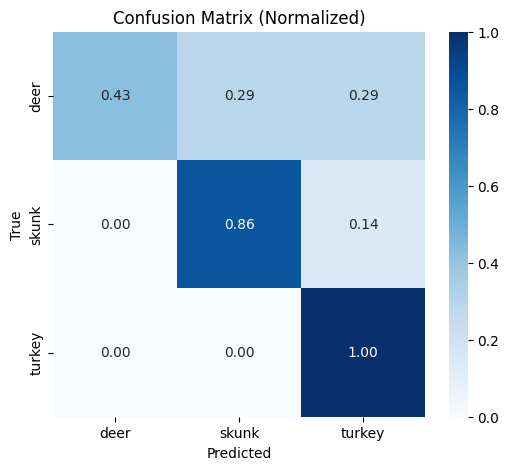

In [12]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=True, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, fmt=".2f")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Normalized)")
plt.show()

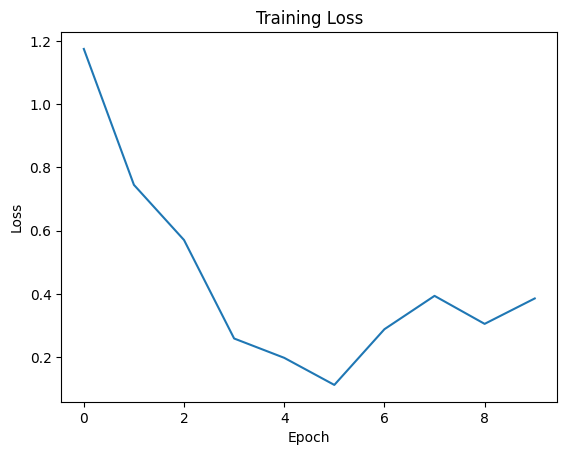

In [13]:
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [14]:
def predict_image(model, image_path, transform, class_names):
    model.eval()
    img = Image.open(image_path).convert("RGB")
    img_t = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_t)
        _, predicted = torch.max(outputs, 1)

    return class_names[predicted.item()]

Prediction: skunk


(-0.5, 1023.5, 767.5, -0.5)

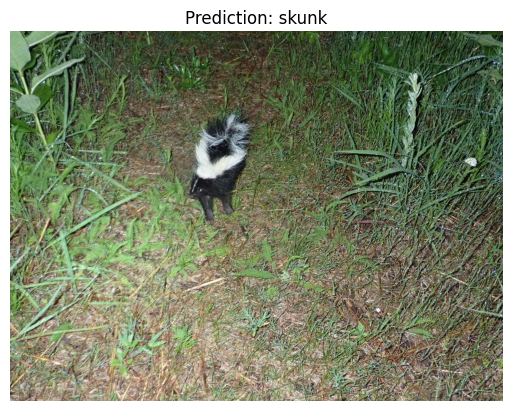

In [17]:
image_path = "C:\\Users\\manni\\Documents\\ai_wildlife_classifier\\data\\test_images\\skunktest.jpg"
prediction = predict_image(model, image_path, transforms_basic, class_names)
print("Prediction:", prediction)

img = Image.open(image_path)
plt.imshow(img)
plt.title(f"Prediction: {prediction}")
plt.axis("off")

In [19]:
torch.save(model.state_dict(), "wildlife_classifier.pth")